Se cargaron exitosamente 142 galaxias desde el archivo.
Analizando la historia de fusiones en los archivos de texto...


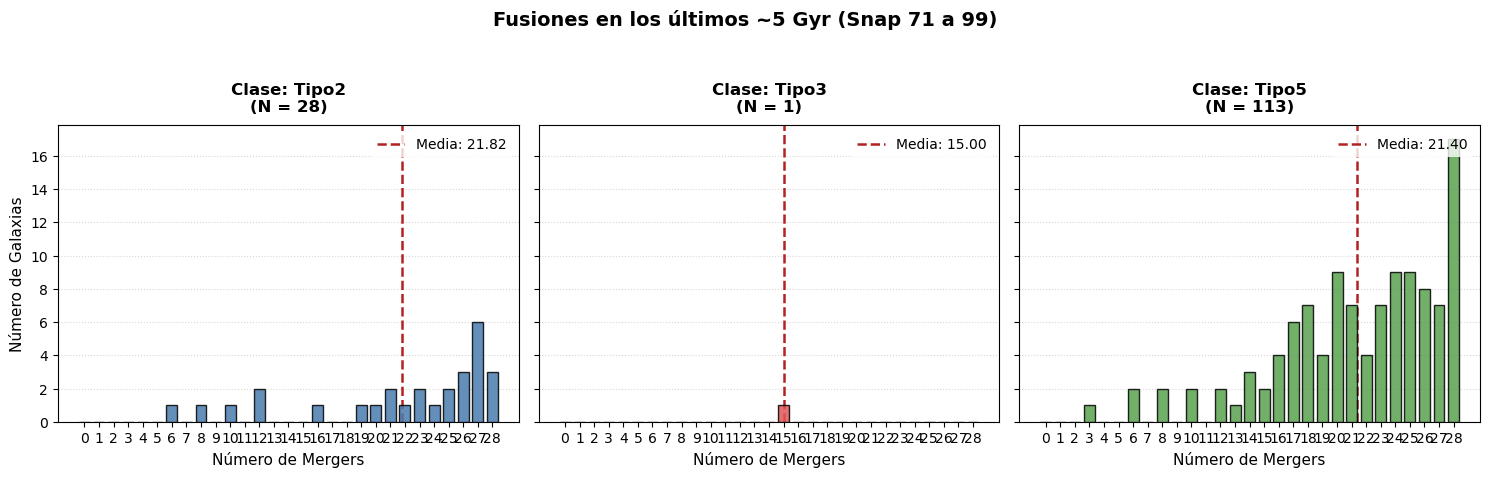

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. TUS DATOS DE ENTRADA Y CONFIGURACIÓN
folder_name = "mergestxt"
snapshot_presente = 99
snap_limite = 71  # Límite temporal: Snap 71 corresponde a ~5 Gyr atrás en TNG100
archivo_tipos = "cls99_2.txt"  # Archivo limpio generado por el script anterior

subhalo_ids = []
tipos_galaxias = []

# Lectura simplificada y directa del nuevo archivo optimizado
if os.path.exists(archivo_tipos):
    with open(archivo_tipos, "r") as f:
        for line in f:
            linea_limpia = line.strip()
            if not linea_limpia:
                continue
                
            partes = linea_limpia.split()
            # Como el archivo está limpio, cada línea tiene exactamente 2 elementos
            if len(partes) == 2:
                tipo = partes[0]
                try:
                    # El ID ya viene sin .png ni extensiones
                    shid_entero = int(partes[1])
                    subhalo_ids.append(shid_entero)
                    tipos_galaxias.append(tipo)
                except ValueError:
                    continue
                    
    print(f"Se cargaron exitosamente {len(subhalo_ids)} galaxias desde el archivo.")
else:
    raise FileNotFoundError(f"No se encontró el archivo de tipos: {archivo_tipos}")

# 2. DICCIONARIO PARA ALMACENAR LOS CONTEOS POR TIPO REAL
conteos_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}

# 3. PROCESAMIENTO DE LOS ARCHIVOS DE EVOLUCIÓN (.TXT)
print("Analizando la historia de fusiones en los archivos de texto...")

for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    filename = f"evolucion_{snapshot_presente}_{sid}.txt"
    file_path = os.path.join(folder_name, filename)
    
    if not os.path.exists(file_path):
        print(f"⚠️ Archivo no encontrado: {filename}. Saltando...")
        continue
        
    mergers_en_rango = 0
    
    with open(file_path, "r") as f:
        lines = f.readlines()
        
        # Saltamos las primeras 3 líneas correspondientes al encabezado
        for line in lines[3:]:
            parts = line.split("|")
            if len(parts) < 5:
                continue
                
            try:
                snap = int(parts[0].strip())
                next_tree_id = int(parts[3].strip())
                
                # Criterios: 
                # 1. Que esté dentro del límite de tiempo (Snap >= 71)
                # 2. Que NextProgenitorID != -1 (significa que hay un merger en ese snap)
                if snap >= snap_limite and next_tree_id != -1:
                    mergers_en_rango += 1
            except ValueError:
                continue
                
    conteos_por_tipo[tipo].append(mergers_en_rango)

# 4. GENERACIÓN DE LOS HISTOGRAMAS POR TIPO
tipos_unicos = sorted(list(conteos_por_tipo.keys()))
n_plots = len(tipos_unicos)

# Determinamos el número máximo de mergers global para homogeneizar el eje X
todos_los_conteos = [c for lista in conteos_por_tipo.values() for c in lista]
max_mergers_global = max(todos_los_conteos) if len(todos_los_conteos) > 0 else 5

# Configuración de los Bins centrados en los enteros [0, 1, 2, ...]
bins = np.arange(0, max_mergers_global + 2) - 0.5

# Creamos la figura con subplots alineados horizontalmente
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4.5), sharey=True)

# Asegurar que axes sea un array indexable si solo hubiese 1 tipo activo
if n_plots == 1:
    axes = [axes]

# Paleta cromática limpia para los tipos detectados (Tipo2, Tipo3, Tipo5)
colores = ['#4A7BB0', '#E15759', '#59A14F']

for i, tipo in enumerate(tipos_unicos):
    ax = axes[i]
    datos_tipo = conteos_por_tipo[tipo]
    n_galaxias = len(datos_tipo)
    
    # Graficar Histograma discreto
    ax.hist(datos_tipo, bins=bins, rwidth=0.75, color=colores[i % len(colores)], 
            edgecolor='black', alpha=0.85, zorder=3)
    
    # Calcular y dibujar la línea de la media
    if n_galaxias > 0:
        media = np.mean(datos_tipo)
        ax.axvline(media, color='#B22222', linestyle='--', linewidth=1.8, 
                   label=f'Media: {media:.2f}')
    
    # Detalles estéticos de cada subplot
    ax.set_title(f"Clase: {tipo}\n(N = {n_galaxias})", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Número de Mergers", fontsize=11)
    
    if i == 0:
        ax.set_ylabel("Número de Galaxias", fontsize=11)
        
    ax.set_xticks(range(0, max_mergers_global + 1))
    ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
    ax.legend(frameon=True, loc='upper right', facecolor='white', edgecolor='none')

plt.suptitle(f"Fusiones en los últimos ~5 Gyr (Snap {snap_limite} a {snapshot_presente})", 
             fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

Se cargaron exitosamente 137 galaxias desde el archivo.
Analizando la historia de fusiones en los archivos de texto...


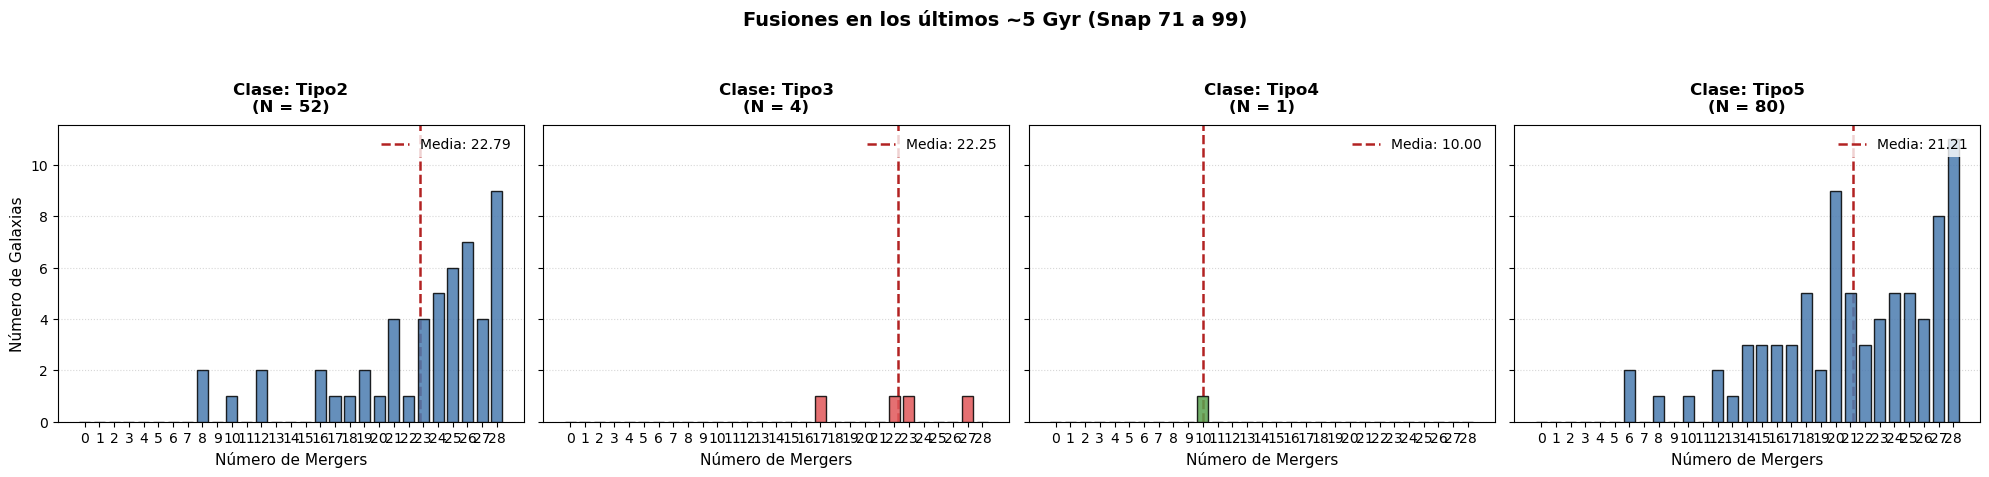

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. TUS DATOS DE ENTRADA Y CONFIGURACIÓN
folder_name = "mergestxt"
snapshot_presente = 99
snap_limite = 71  # Límite temporal: Snap 71 corresponde a ~5 Gyr atrás en TNG100
archivo_tipos = "cls99.txt"  # Archivo limpio generado por el script anterior

subhalo_ids = []
tipos_galaxias = []

# Lectura simplificada y directa del nuevo archivo optimizado
if os.path.exists(archivo_tipos):
    with open(archivo_tipos, "r") as f:
        for line in f:
            linea_limpia = line.strip()
            if not linea_limpia:
                continue
                
            partes = linea_limpia.split()
            # Como el archivo está limpio, cada línea tiene exactamente 2 elementos
            if len(partes) == 2:
                tipo = partes[0]
                try:
                    # El ID ya viene sin .png ni extensiones
                    shid_entero = int(partes[1])
                    subhalo_ids.append(shid_entero)
                    tipos_galaxias.append(tipo)
                except ValueError:
                    continue
                    
    print(f"Se cargaron exitosamente {len(subhalo_ids)} galaxias desde el archivo.")
else:
    raise FileNotFoundError(f"No se encontró el archivo de tipos: {archivo_tipos}")

# 2. DICCIONARIO PARA ALMACENAR LOS CONTEOS POR TIPO REAL
conteos_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}

# 3. PROCESAMIENTO DE LOS ARCHIVOS DE EVOLUCIÓN (.TXT)
print("Analizando la historia de fusiones en los archivos de texto...")

for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    filename = f"evolucion_{snapshot_presente}_{sid}.txt"
    file_path = os.path.join(folder_name, filename)
    
    if not os.path.exists(file_path):
        print(f"⚠️ Archivo no encontrado: {filename}. Saltando...")
        continue
        
    mergers_en_rango = 0
    
    with open(file_path, "r") as f:
        lines = f.readlines()
        
        # Saltamos las primeras 3 líneas correspondientes al encabezado
        for line in lines[3:]:
            parts = line.split("|")
            if len(parts) < 5:
                continue
                
            try:
                snap = int(parts[0].strip())
                next_tree_id = int(parts[3].strip())
                
                # Criterios: 
                # 1. Que esté dentro del límite de tiempo (Snap >= 71)
                # 2. Que NextProgenitorID != -1 (significa que hay un merger en ese snap)
                if snap >= snap_limite and next_tree_id != -1:
                    mergers_en_rango += 1
            except ValueError:
                continue
                
    conteos_por_tipo[tipo].append(mergers_en_rango)

# 4. GENERACIÓN DE LOS HISTOGRAMAS POR TIPO
tipos_unicos = sorted(list(conteos_por_tipo.keys()))
n_plots = len(tipos_unicos)

# Determinamos el número máximo de mergers global para homogeneizar el eje X
todos_los_conteos = [c for lista in conteos_por_tipo.values() for c in lista]
max_mergers_global = max(todos_los_conteos) if len(todos_los_conteos) > 0 else 5

# Configuración de los Bins centrados en los enteros [0, 1, 2, ...]
bins = np.arange(0, max_mergers_global + 2) - 0.5

# Creamos la figura con subplots alineados horizontalmente
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4.5), sharey=True)

# Asegurar que axes sea un array indexable si solo hubiese 1 tipo activo
if n_plots == 1:
    axes = [axes]

# Paleta cromática limpia para los tipos detectados (Tipo2, Tipo3, Tipo5)
colores = ['#4A7BB0', '#E15759', '#59A14F']

for i, tipo in enumerate(tipos_unicos):
    ax = axes[i]
    datos_tipo = conteos_por_tipo[tipo]
    n_galaxias = len(datos_tipo)
    
    # Graficar Histograma discreto
    ax.hist(datos_tipo, bins=bins, rwidth=0.75, color=colores[i % len(colores)], 
            edgecolor='black', alpha=0.85, zorder=3)
    
    # Calcular y dibujar la línea de la media
    if n_galaxias > 0:
        media = np.mean(datos_tipo)
        ax.axvline(media, color='#B22222', linestyle='--', linewidth=1.8, 
                   label=f'Media: {media:.2f}')
    
    # Detalles estéticos de cada subplot
    ax.set_title(f"Clase: {tipo}\n(N = {n_galaxias})", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Número de Mergers", fontsize=11)
    
    if i == 0:
        ax.set_ylabel("Número de Galaxias", fontsize=11)
        
    ax.set_xticks(range(0, max_mergers_global + 1))
    ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
    ax.legend(frameon=True, loc='upper right', facecolor='white', edgecolor='none')

plt.suptitle(f"Fusiones en los últimos ~5 Gyr (Snap {snap_limite} a {snapshot_presente})", 
             fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

Se cargaron 142 galaxias del archivo morfológico.
Cargando masas desde el catálogo de grupos local...


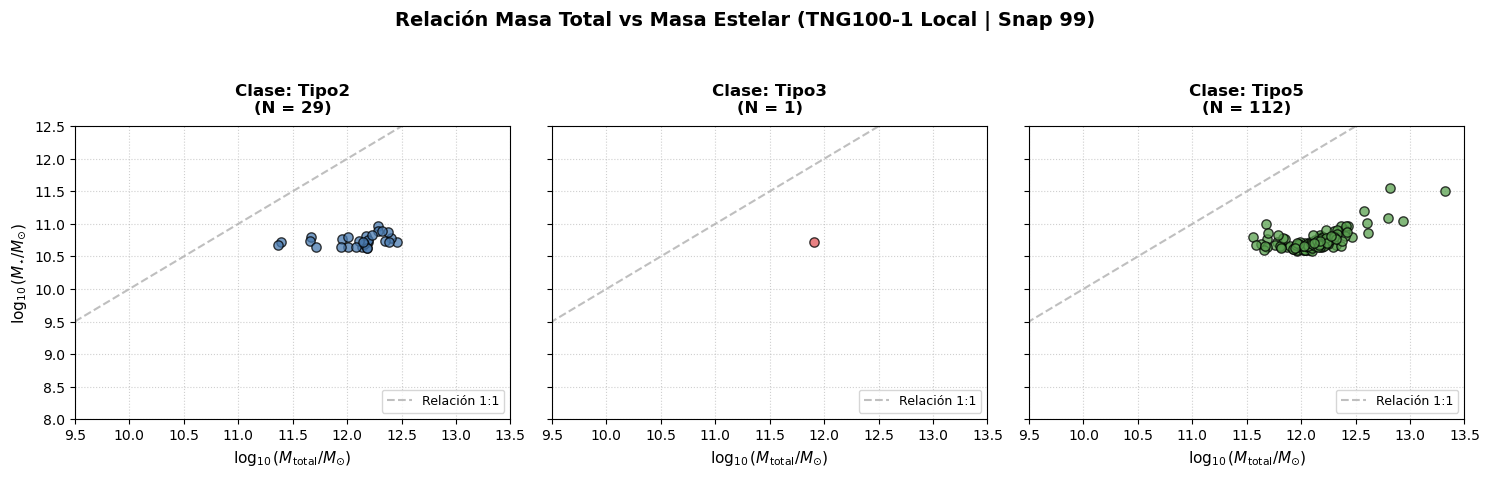

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il  # Asegúrate de tener cargado tu módulo oficial

# 1. TUS DATOS DE ENTRADA Y CONFIGURACIÓN LOCAL
basePath = '/home/tnguser/sims.TNG/TNG100-1/output/'
snapshot_presente = 99
archivo_tipos = "types_shid_sn99_1.txt"  # Tu archivo limpio de clasificaciones

# Cargar el Header una sola vez para optimizar y obtener el parámetro de Hubble
header = il.groupcat.loadHeader(basePath, snapshot_presente)
h = header['HubbleParam']        # ~0.6774

subhalo_ids = []
tipos_galaxias = []

# Cargar las clasificaciones morfológicas locales
if os.path.exists(archivo_tipos):
    with open(archivo_tipos, "r") as f:
        for line in f:
            linea_limpia = line.strip()
            if not linea_limpia:
                continue
            partes = linea_limpia.split()
            if len(partes) == 2:
                subhalo_ids.append(int(partes[1]))
                tipos_galaxias.append(partes[0])
    print(f"Se cargaron {len(subhalo_ids)} galaxias del archivo morfológico.")
else:
    raise FileNotFoundError(f"No se encontró el archivo: {archivo_tipos}")

# Diccionarios para almacenar las masas físicas reales (en M_sun) por tipo
masas_totales_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_estelares_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_gas_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}

# 2. LECTURA DIRECTA DE LA SIMULACIÓN CON ILLUSTRIS_PYTHON
print("Cargando masas desde el catálogo de grupos local...")

for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    try:
        # Carga el subhalo individual desde el catálogo del Snap 99
        subhalo = il.groupcat.loadSingle(basePath, snapshot_presente, subhaloID=sid)
        
        # --- EXTRACCIÓN Y CONVERSIÓN A UNIDADES FÍSICAS (M_sun) ---
        # SubhaloMass contiene la masa total ligada gravitacionalmente en 1e10 M_sun/h
        m_total_fisica = subhalo['SubhaloMass'] * 1e10 / h
        
        # SubhaloMassType es un array de 6 elementos correspondientes a los tipos de partículas:
        # [0: Gas, 1: Dark Matter, 2: Sin uso, 3: Tracers, 4: Stars/Wind, 5: Black Holes]
        m_gas_fisica = subhalo['SubhaloMassType'][0] * 1e10 / h
        m_estelar_fisica = subhalo['SubhaloMassType'][4] * 1e10 / h
        
        # Filtramos valores mayores a 0 para poder aplicar escala logarítmica sin errores
        if m_total_fisica > 0 and m_estelar_fisica > 0:
            masas_totales_por_tipo[tipo].append(np.log10(m_total_fisica))
            masas_estelares_por_tipo[tipo].append(np.log10(m_estelar_fisica))
            masas_gas_por_tipo[tipo].append(np.log10(m_gas_fisica) if m_gas_fisica > 0 else 0)
            
    except Exception as e:
        print(f"⚠️ Error al cargar el subhalo {sid}: {e}")
        continue

# 3. GENERACIÓN DE LOS SCATTER PLOTS POR CLASIFICACIÓN
tipos_unicos = sorted(list(masas_totales_por_tipo.keys()))
n_plots = len(tipos_unicos)

# Creamos subplots dinámicos según las clasificaciones encontradas
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4.5), sharex=True, sharey=True)

if n_plots == 1:
    axes = [axes]

colores = ['#4A7BB0', '#E15759', '#59A14F']
nombre_eje_y = "Masa Estelar"  # <--- Cambia a "Masa del Gas" si decides graficar 'masas_gas_por_tipo' abajo

for i, tipo in enumerate(tipos_unicos):
    ax = axes[i]
    x = masas_totales_por_tipo[tipo]
    y = masas_estelares_por_tipo[tipo]  # <--- Cambia aquí por masas_gas_por_tipo[tipo] para ver Gas vs M_total
    
    # Gráfico de dispersión (Scatter Plot)
    ax.scatter(x, y, color=colores[i % len(colores)], edgecolor='black', alpha=0.75, s=45, zorder=3)
    
    # Dibujar línea de referencia identidad 1:1
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot([8, 14], [8, 14], color='gray', linestyle='--', alpha=0.5, zorder=1, label='Relación 1:1')
    
    # Formato estético
    ax.set_title(f"Clase: {tipo}\n(N = {len(x)})", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(r"$\log_{10}(M_{\mathrm{total}} / M_{\odot})$", fontsize=11)
    
    if i == 0:
        ax.set_ylabel(r"$\log_{10}(M_{\star} / M_{\odot})$", fontsize=11)
        
    ax.set_xlim(9.5, 13.5)
    ax.set_ylim(8.0, 12.5)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle(f"Relación Masa Total vs {nombre_eje_y} (TNG100-1 Local | Snap {snapshot_presente})", 
             fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

Se cargaron 142 galaxias del archivo morfológico.
Cargando masas desde el catálogo de grupos local...


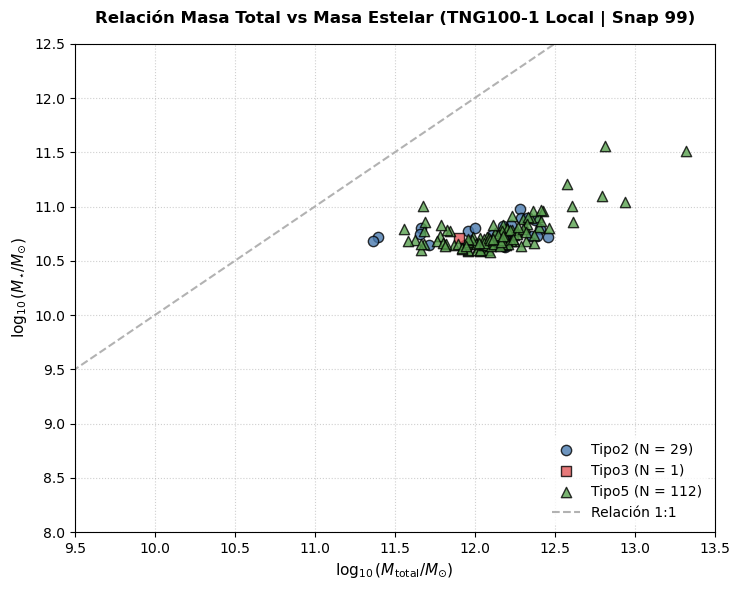

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il  

# 1. TUS DATOS DE ENTRADA Y CONFIGURACIÓN LOCAL
basePath = '/home/tnguser/sims.TNG/TNG100-1/output/'
snapshot_presente = 99
archivo_tipos = "types_shid_sn99_1.txt"  

# Cargar el Header una sola vez para optimizar y obtener el parámetro de Hubble
header = il.groupcat.loadHeader(basePath, snapshot_presente)
h = header['HubbleParam']        # ~0.6774

subhalo_ids = []
tipos_galaxias = []

# Cargar las clasificaciones morfológicas locales
if os.path.exists(archivo_tipos):
    with open(archivo_tipos, "r") as f:
        for line in f:
            linea_limpia = line.strip()
            if not linea_limpia:
                continue
            partes = linea_limpia.split()
            if len(partes) == 2:
                subhalo_ids.append(int(partes[1]))
                tipos_galaxias.append(partes[0])
    print(f"Se cargaron {len(subhalo_ids)} galaxias del archivo morfológico.")
else:
    raise FileNotFoundError(f"No se encontró el archivo: {archivo_tipos}")

# Diccionarios para almacenar las masas físicas reales (en M_sun) por tipo
masas_totales_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_estelares_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_gas_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}

# 2. LECTURA DIRECTA DE LA SIMULACIÓN CON ILLUSTRIS_PYTHON
print("Cargando masas desde el catálogo de grupos local...")

for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    try:
        subhalo = il.groupcat.loadSingle(basePath, snapshot_presente, subhaloID=sid)
        
        # --- EXTRACCIÓN Y CONVERSIÓN A UNIDADES FÍSICAS (M_sun) ---
        m_total_fisica = subhalo['SubhaloMass'] * 1e10 / h
        m_gas_fisica = subhalo['SubhaloMassType'][0] * 1e10 / h
        m_estelar_fisica = subhalo['SubhaloMassType'][4] * 1e10 / h
        
        if m_total_fisica > 0 and m_estelar_fisica > 0:
            masas_totales_por_tipo[tipo].append(np.log10(m_total_fisica))
            masas_estelares_por_tipo[tipo].append(np.log10(m_estelar_fisica))
            masas_gas_por_tipo[tipo].append(np.log10(m_gas_fisica) if m_gas_fisica > 0 else 0)
            
    except Exception as e:
        print(f"⚠️ Error al cargar el subhalo {sid}: {e}")
        continue

# 3. GENERACIÓN DEL GRÁFICO UNIFICADO (UN SOLO CUADRO)
plt.figure(figsize=(7.5, 6))

tipos_unicos = sorted(list(masas_totales_por_tipo.keys()))

# Diccionarios de estilos para mapear cada tipo a un color y marcador único
colores = {'Tipo2': '#4A7BB0', 'Tipo3': '#E15759', 'Tipo5': '#59A14F'}
marcadores = {'Tipo2': 'o', 'Tipo3': 's', 'Tipo5': '^'} # Círculo, Cuadrado, Triángulo

nombre_eje_y = "Masa Estelar"  # <--- Cambia a "Masa del Gas" si usas masas_gas_por_tipo abajo

# Dibujar las poblaciones de galaxias iterando en el mismo cuadro
for tipo in tipos_unicos:
    x = masas_totales_por_tipo[tipo]
    y = masas_estelares_por_tipo[tipo]  # <--- Cambia aquí por masas_gas_por_tipo[tipo] si prefieres Gas
    
    plt.scatter(x, y, 
                color=colores.get(tipo, '#76b7b2'), 
                marker=marcadores.get(tipo, 'o'),
                edgecolor='black', 
                alpha=0.8, 
                s=55, 
                label=f"{tipo} (N = {len(x)})", 
                zorder=3)

# Dibujar línea de referencia identidad 1:1 unificada
plt.plot([8, 14], [8, 14], color='gray', linestyle='--', alpha=0.6, label='Relación 1:1', zorder=1)

# Ajustes estéticos y etiquetas del cuadro único
plt.title(f"Relación Masa Total vs {nombre_eje_y} (TNG100-1 Local | Snap {snapshot_presente})", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel(r"$\log_{10}(M_{\mathrm{total}} / M_{\odot})$", fontsize=11)

if nombre_eje_y == "Masa Estelar":
    plt.ylabel(r"$\log_{10}(M_{\star} / M_{\odot})$", fontsize=11)
else:
    plt.ylabel(r"$\log_{10}(M_{\mathrm{gas}} / M_{\odot})$", fontsize=11)

# Límites fijos para una visualización consistente
plt.xlim(9.5, 13.5)
plt.ylim(8.0, 12.5)

plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()

Se cargaron 142 galaxias del archivo morfológico.
Cargando masas desde el catálogo de grupos local...


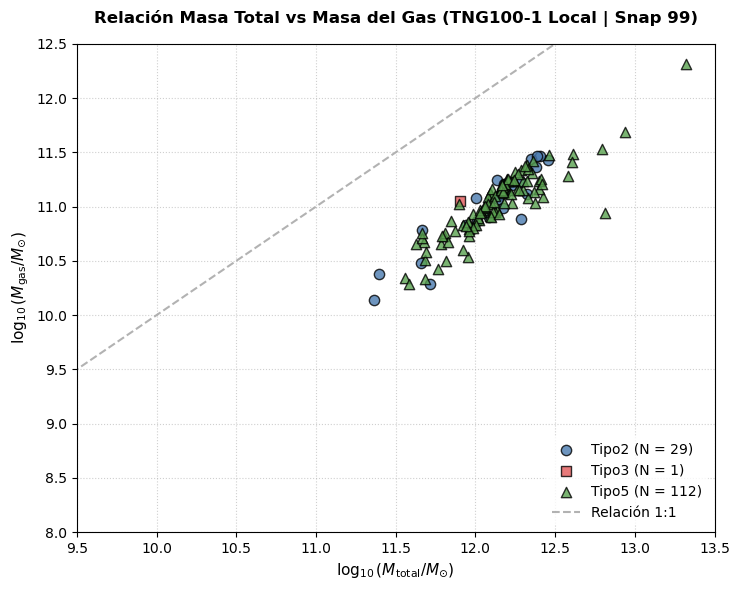

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il  

# 1. TUS DATOS DE ENTRADA Y CONFIGURACIÓN LOCAL
basePath = '/home/tnguser/sims.TNG/TNG100-1/output/'
snapshot_presente = 99
archivo_tipos = "types_shid_sn99_1.txt"  

# Cargar el Header una sola vez para obtener el parámetro de Hubble
header = il.groupcat.loadHeader(basePath, snapshot_presente)
h = header['HubbleParam']        # ~0.6774

subhalo_ids = []
tipos_galaxias = []

# Cargar las clasificaciones morfológicas locales
if os.path.exists(archivo_tipos):
    with open(archivo_tipos, "r") as f:
        for line in f:
            linea_limpia = line.strip()
            if not linea_limpia:
                continue
            partes = linea_limpia.split()
            if len(partes) == 2:
                subhalo_ids.append(int(partes[1]))
                tipos_galaxias.append(partes[0])
    print(f"Se cargaron {len(subhalo_ids)} galaxias del archivo morfológico.")
else:
    raise FileNotFoundError(f"No se encontró el archivo: {archivo_tipos}")

# Diccionarios para almacenar las masas físicas reales (en M_sun) por tipo
masas_totales_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_estelares_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_gas_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}

# 2. LECTURA DIRECTA DE LA SIMULACIÓN CON ILLUSTRIS_PYTHON
print("Cargando masas desde el catálogo de grupos local...")

for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    try:
        subhalo = il.groupcat.loadSingle(basePath, snapshot_presente, subhaloID=sid)
        
        # --- EXTRACCIÓN Y CONVERSIÓN A UNIDADES FÍSICAS REALES (M_sun) ---
        # Masa total del subhalo (Materia oscura + Gas + Estrellas + BHs)
        m_total_fisica = subhalo['SubhaloMass'] * 1e10 / h
        
        # Masa de Gas (Índice 0) y Masa Estelar (Índice 4)
        m_gas_fisica = subhalo['SubhaloMassType'][0] * 1e10 / h
        m_estelar_fisica = subhalo['SubhaloMassType'][4] * 1e10 / h
        
        # Filtramos que los valores sean mayores a 0 para evitar errores con el log10
        if m_total_fisica > 0:
            masas_totales_por_tipo[tipo].append(np.log10(m_total_fisica))
            
            # Si la masa estelar es cero (galaxias oscuras), guardamos un valor bajo o la saltamos
            masas_estelares_por_tipo[tipo].append(np.log10(m_estelar_fisica) if m_estelar_fisica > 0 else 0)
            masas_gas_por_tipo[tipo].append(np.log10(m_gas_fisica) if m_gas_fisica > 0 else 0)
            
    except Exception as e:
        continue

# 3. GENERACIÓN DEL GRÁFICO UNIFICADO (UN SOLO CUADRO)
plt.figure(figsize=(7.5, 6))

tipos_unicos = sorted(list(masas_totales_por_tipo.keys()))

# Diccionarios de estilos estéticos para mapear cada tipo morfológico
colores = {'Tipo2': '#4A7BB0', 'Tipo3': '#E15759', 'Tipo5': '#59A14F'}
marcadores = {'Tipo2': 'o', 'Tipo3': 's', 'Tipo5': '^'} 

# =========================================================================
# CONFIGURACIÓN DE LA COMPONENTE A GRAFICAR
# Cambia 'ESTELAR' por 'GAS' si prefieres ver la masa del gas en el eje Y
COMPONENTE = 'GAS' 
# =========================================================================

# Dibujar las poblaciones de galaxias iterando en el mismo cuadro
for tipo in tipos_unicos:
    x = masas_totales_por_tipo[tipo]
    
    # Selección dinámica de la componente según tu elección
    if COMPONENTE == 'ESTELAR':
        y = masas_estelares_por_tipo[tipo]
        label_y = r"$\log_{10}(M_{\star} / M_{\odot})$"
        titulo_componente = "Masa Estelar"
    else:
        y = masas_gas_por_tipo[tipo]
        label_y = r"$\log_{10}(M_{\mathrm{gas}} / M_{\odot})$"
        titulo_componente = "Masa del Gas"
    
    plt.scatter(x, y, 
                color=colores.get(tipo, '#76b7b2'), 
                marker=marcadores.get(tipo, 'o'),
                edgecolor='black', 
                alpha=0.8, 
                s=55, 
                label=f"{tipo} (N = {len(x)})", 
                zorder=3)

# Dibujar línea de referencia identidad 1:1 unificada
# Ahora los datos sí se acercarán a esta línea porque M_star y M_total están en rangos similares
plt.plot([8, 14], [8, 14], color='gray', linestyle='--', alpha=0.6, label='Relación 1:1', zorder=1)

# Ajustes estéticos y etiquetas del cuadro único
plt.title(f"Relación Masa Total vs {titulo_componente} (TNG100-1 Local | Snap {snapshot_presente})", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel(r"$\log_{10}(M_{\mathrm{total}} / M_{\odot})$", fontsize=11)
plt.ylabel(label_y, fontsize=11)

# Límites fijos optimizados para Masa Estelar y Masa Total
plt.xlim(9.5, 13.5)
plt.ylim(8.0, 12.5)

plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()

Se cargaron 142 galaxias del archivo morfológico.
Cargando masas desde el catálogo de grupos local...


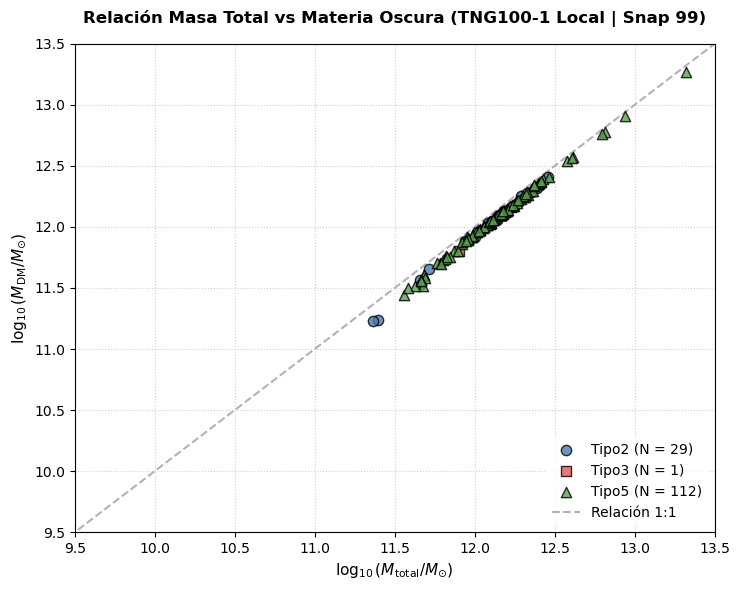

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il  

# 1. TUS DATOS DE ENTRADA Y CONFIGURACIÓN LOCAL
basePath = '/home/tnguser/sims.TNG/TNG100-1/output/'
snapshot_presente = 99
archivo_tipos = "types_shid_sn99_1.txt"  

# Cargar el Header una sola vez para optimizar y obtener el parámetro de Hubble
header = il.groupcat.loadHeader(basePath, snapshot_presente)
h = header['HubbleParam']        # ~0.6774

subhalo_ids = []
tipos_galaxias = []

# Cargar las clasificaciones morfológicas locales
if os.path.exists(archivo_tipos):
    with open(archivo_tipos, "r") as f:
        for line in f:
            linea_limpia = line.strip()
            if not linea_limpia:
                continue
            partes = linea_limpia.split()
            if len(partes) == 2:
                subhalo_ids.append(int(partes[1]))
                tipos_galaxias.append(partes[0])
    print(f"Se cargaron {len(subhalo_ids)} galaxias del archivo morfológico.")
else:
    raise FileNotFoundError(f"No se encontró el archivo: {archivo_tipos}")

# Diccionarios para almacenar las masas físicas reales (en M_sun) por tipo
masas_totales_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_estelares_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_gas_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_dm_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_bh_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}

# 2. LECTURA DIRECTA DE LA SIMULACIÓN CON ILLUSTRIS_PYTHON
print("Cargando masas desde el catálogo de grupos local...")

for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    try:
        subhalo = il.groupcat.loadSingle(basePath, snapshot_presente, subhaloID=sid)
        
        # --- EXTRACCIÓN Y CONVERSIÓN A UNIDADES FÍSICAS REALES (M_sun) ---
        m_total_fisica = subhalo['SubhaloMass'] * 1e10 / h
        
        # Mapeo de SubhaloMassType: [0:Gas, 1:DM, 2:Unused, 3:Tracers, 4:Stars, 5:BHs]
        m_gas_fisica = subhalo['SubhaloMassType'][0] * 1e10 / h
        m_dm_fisica = subhalo['SubhaloMassType'][1] * 1e10 / h
        m_estelar_fisica = subhalo['SubhaloMassType'][4] * 1e10 / h
        m_bh_fisica = subhalo['SubhaloMassType'][5] * 1e10 / h
        
        if m_total_fisica > 0:
            masas_totales_por_tipo[tipo].append(np.log10(m_total_fisica))
            masas_estelares_por_tipo[tipo].append(np.log10(m_estelar_fisica) if m_estelar_fisica > 0 else 0)
            masas_gas_por_tipo[tipo].append(np.log10(m_gas_fisica) if m_gas_fisica > 0 else 0)
            masas_dm_por_tipo[tipo].append(np.log10(m_dm_fisica) if m_dm_fisica > 0 else 0)
            masas_bh_por_tipo[tipo].append(np.log10(m_bh_fisica) if m_bh_fisica > 0 else 0)
            
    except Exception as e:
        continue

# 3. GENERACIÓN DEL GRÁFICO UNIFICADO (UN SOLO CUADRO)
plt.figure(figsize=(7.5, 6))

tipos_unicos = sorted(list(masas_totales_por_tipo.keys()))

colores = {'Tipo2': '#4A7BB0', 'Tipo3': '#E15759', 'Tipo5': '#59A14F'}
marcadores = {'Tipo2': 'o', 'Tipo3': 's', 'Tipo5': '^'} 

# =========================================================================
# CONFIGURACIÓN DE LA COMPONENTE A GRAFICAR
# Elige una opción: 'DM' (Materia Oscura), 'BH' (Agujero Negro), 'ESTELAR' o 'GAS'
COMPONENTE = 'DM'  
# =========================================================================

# Ajuste dinámico de etiquetas y límites según la componente elegida
if COMPONENTE == 'DM':
    diccionario_y = masas_dm_por_tipo
    label_y = r"$\log_{10}(M_{\mathrm{DM}} / M_{\odot})$"
    titulo_componente = "Materia Oscura"
    ylim_inf, ylim_sup = 9.5, 13.5  # La DM sigue muy de cerca a la masa total
elif COMPONENTE == 'BH':
    diccionario_y = masas_bh_por_tipo
    label_y = r"$\log_{10}(M_{\bullet} / M_{\odot})$"
    titulo_componente = "Agujeros Negros"
    ylim_inf, ylim_sup = 6.0, 11.5  # Los BHs son mucho menos masivos
elif COMPONENTE == 'ESTELAR':
    diccionario_y = masas_estelares_por_tipo
    label_y = r"$\log_{10}(M_{\star} / M_{\odot})$"
    titulo_componente = "Masa Estelar"
    ylim_inf, ylim_sup = 8.0, 12.5
else:
    diccionario_y = masas_gas_por_tipo
    label_y = r"$\log_{10}(M_{\mathrm{gas}} / M_{\odot})$"
    titulo_componente = "Masa del Gas"
    ylim_inf, ylim_sup = 8.0, 12.5

# Dibujar las poblaciones de galaxias iterando en el mismo cuadro
for tipo in tipos_unicos:
    x = masas_totales_por_tipo[tipo]
    y = diccionario_y[tipo]
    
    plt.scatter(x, y, 
                color=colores.get(tipo, '#76b7b2'), 
                marker=marcadores.get(tipo, 'o'),
                edgecolor='black', 
                alpha=0.8, 
                s=55, 
                label=f"{tipo} (N = {len(x)})", 
                zorder=3)

# Dibujar línea de referencia identidad 1:1 unificada
plt.plot([6, 14], [6, 14], color='gray', linestyle='--', alpha=0.6, label='Relación 1:1', zorder=1)

# Ajustes estéticos y etiquetas del cuadro único
plt.title(f"Relación Masa Total vs {titulo_componente} (TNG100-1 Local | Snap {snapshot_presente})", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel(r"$\log_{10}(M_{\mathrm{total}} / M_{\odot})$", fontsize=11)
plt.ylabel(label_y, fontsize=11)

# Definir límites dinámicos
plt.xlim(9.5, 13.5)
plt.ylim(ylim_inf, ylim_sup)

plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()

Se cargaron 142 galaxias del archivo morfológico.
Cargando masas desde el catálogo de grupos local...


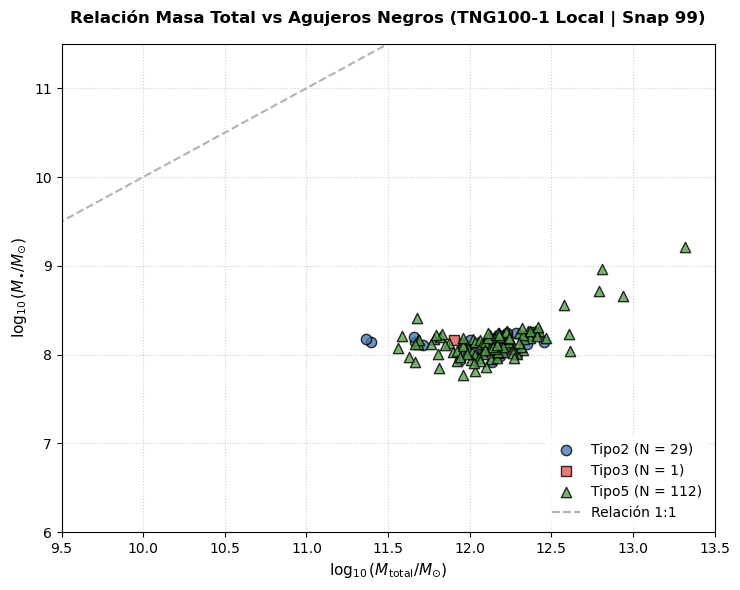

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il  

# 1. TUS DATOS DE ENTRADA Y CONFIGURACIÓN LOCAL
basePath = '/home/tnguser/sims.TNG/TNG100-1/output/'
snapshot_presente = 99
archivo_tipos = "types_shid_sn99_1.txt"  

# Cargar el Header una sola vez para optimizar y obtener el parámetro de Hubble
header = il.groupcat.loadHeader(basePath, snapshot_presente)
h = header['HubbleParam']        # ~0.6774

subhalo_ids = []
tipos_galaxias = []

# Cargar las clasificaciones morfológicas locales
if os.path.exists(archivo_tipos):
    with open(archivo_tipos, "r") as f:
        for line in f:
            linea_limpia = line.strip()
            if not linea_limpia:
                continue
            partes = linea_limpia.split()
            if len(partes) == 2:
                subhalo_ids.append(int(partes[1]))
                tipos_galaxias.append(partes[0])
    print(f"Se cargaron {len(subhalo_ids)} galaxias del archivo morfológico.")
else:
    raise FileNotFoundError(f"No se encontró el archivo: {archivo_tipos}")

# Diccionarios para almacenar las masas físicas reales (en M_sun) por tipo
masas_totales_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_estelares_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_gas_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_dm_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}
masas_bh_por_tipo = {tipo: [] for tipo in set(tipos_galaxias)}

# 2. LECTURA DIRECTA DE LA SIMULACIÓN CON ILLUSTRIS_PYTHON
print("Cargando masas desde el catálogo de grupos local...")

for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    try:
        subhalo = il.groupcat.loadSingle(basePath, snapshot_presente, subhaloID=sid)
        
        # --- EXTRACCIÓN Y CONVERSIÓN A UNIDADES FÍSICAS REALES (M_sun) ---
        m_total_fisica = subhalo['SubhaloMass'] * 1e10 / h
        
        # Mapeo de SubhaloMassType: [0:Gas, 1:DM, 2:Unused, 3:Tracers, 4:Stars, 5:BHs]
        m_gas_fisica = subhalo['SubhaloMassType'][0] * 1e10 / h
        m_dm_fisica = subhalo['SubhaloMassType'][1] * 1e10 / h
        m_estelar_fisica = subhalo['SubhaloMassType'][4] * 1e10 / h
        m_bh_fisica = subhalo['SubhaloMassType'][5] * 1e10 / h
        
        if m_total_fisica > 0:
            masas_totales_por_tipo[tipo].append(np.log10(m_total_fisica))
            masas_estelares_por_tipo[tipo].append(np.log10(m_estelar_fisica) if m_estelar_fisica > 0 else 0)
            masas_gas_por_tipo[tipo].append(np.log10(m_gas_fisica) if m_gas_fisica > 0 else 0)
            masas_dm_por_tipo[tipo].append(np.log10(m_dm_fisica) if m_dm_fisica > 0 else 0)
            masas_bh_por_tipo[tipo].append(np.log10(m_bh_fisica) if m_bh_fisica > 0 else 0)
            
    except Exception as e:
        continue

# 3. GENERACIÓN DEL GRÁFICO UNIFICADO (UN SOLO CUADRO)
plt.figure(figsize=(7.5, 6))

tipos_unicos = sorted(list(masas_totales_por_tipo.keys()))

colores = {'Tipo2': '#4A7BB0', 'Tipo3': '#E15759', 'Tipo5': '#59A14F'}
marcadores = {'Tipo2': 'o', 'Tipo3': 's', 'Tipo5': '^'} 

# =========================================================================
# CONFIGURACIÓN DE LA COMPONENTE A GRAFICAR
# Elige una opción: 'DM' (Materia Oscura), 'BH' (Agujero Negro), 'ESTELAR' o 'GAS'
COMPONENTE = 'BH'  
# =========================================================================

# Ajuste dinámico de etiquetas y límites según la componente elegida
if COMPONENTE == 'DM':
    diccionario_y = masas_dm_por_tipo
    label_y = r"$\log_{10}(M_{\mathrm{DM}} / M_{\odot})$"
    titulo_componente = "Materia Oscura"
    ylim_inf, ylim_sup = 9.5, 13.5  # La DM sigue muy de cerca a la masa total
elif COMPONENTE == 'BH':
    diccionario_y = masas_bh_por_tipo
    label_y = r"$\log_{10}(M_{\bullet} / M_{\odot})$"
    titulo_componente = "Agujeros Negros"
    ylim_inf, ylim_sup = 6.0, 11.5  # Los BHs son mucho menos masivos
elif COMPONENTE == 'ESTELAR':
    diccionario_y = masas_estelares_por_tipo
    label_y = r"$\log_{10}(M_{\star} / M_{\odot})$"
    titulo_componente = "Masa Estelar"
    ylim_inf, ylim_sup = 8.0, 12.5
else:
    diccionario_y = masas_gas_por_tipo
    label_y = r"$\log_{10}(M_{\mathrm{gas}} / M_{\odot})$"
    titulo_componente = "Masa del Gas"
    ylim_inf, ylim_sup = 8.0, 12.5

# Dibujar las poblaciones de galaxias iterando en el mismo cuadro
for tipo in tipos_unicos:
    x = masas_totales_por_tipo[tipo]
    y = diccionario_y[tipo]
    
    plt.scatter(x, y, 
                color=colores.get(tipo, '#76b7b2'), 
                marker=marcadores.get(tipo, 'o'),
                edgecolor='black', 
                alpha=0.8, 
                s=55, 
                label=f"{tipo} (N = {len(x)})", 
                zorder=3)

# Dibujar línea de referencia identidad 1:1 unificada
plt.plot([6, 14], [6, 14], color='gray', linestyle='--', alpha=0.6, label='Relación 1:1', zorder=1)

# Ajustes estéticos y etiquetas del cuadro único
plt.title(f"Relación Masa Total vs {titulo_componente} (TNG100-1 Local | Snap {snapshot_presente})", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel(r"$\log_{10}(M_{\mathrm{total}} / M_{\odot})$", fontsize=11)
plt.ylabel(label_y, fontsize=11)

# Definir límites dinámicos
plt.xlim(9.5, 13.5)
plt.ylim(ylim_inf, ylim_sup)

plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()

Cargadas 142 galaxias desde el archivo de tipos.
Cargando árboles y buscando mergers directamente de la simulación...


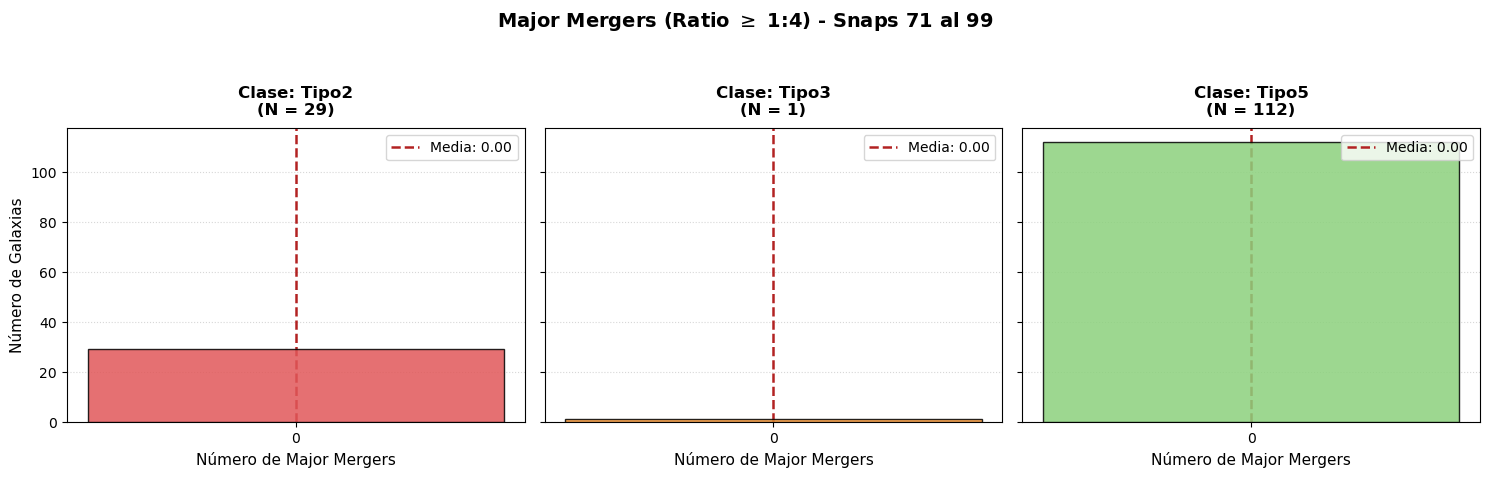

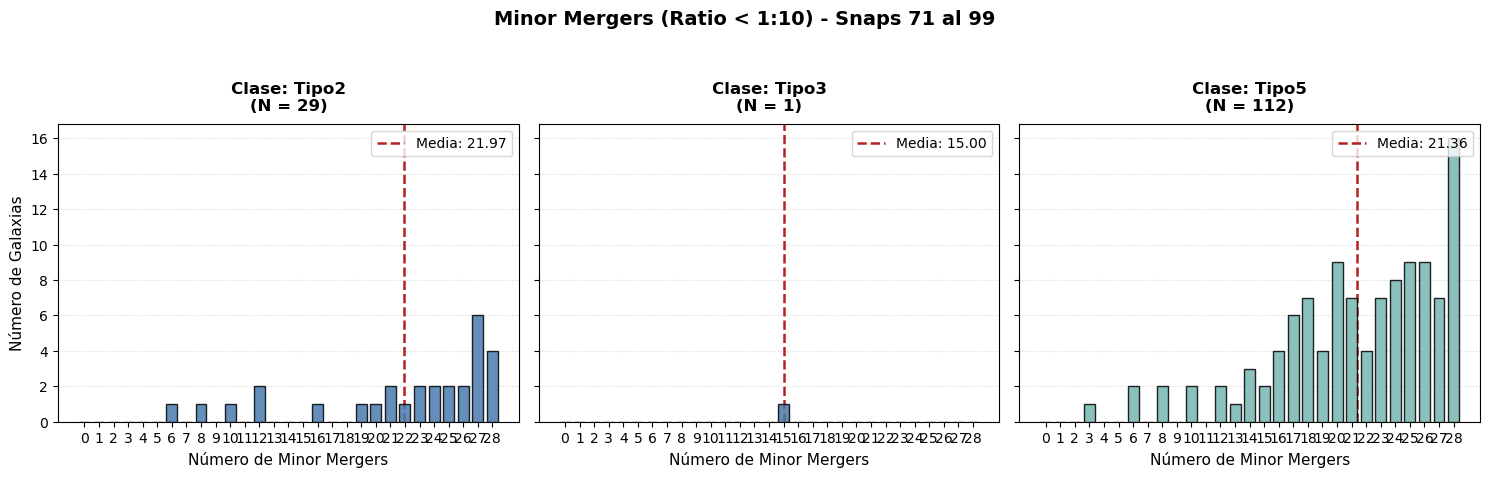

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

# ==========================================
# 1. CONFIGURACIÓN DEL PATH DE LA SIMULACIÓN
# ==========================================
basePath = '/home/tnguser/sims.TNG/TNG100-1/output/' 
snapshot_presente = 99
snap_limite = 71  # ~5 Gyr atrás

archivo_tipos = "types_shid_sn99_1.txt"
subhalo_ids = []
tipos_galaxias = []

if os.path.exists(archivo_tipos):
    with open(archivo_tipos, "r") as f:
        for line in f:
            partes = line.strip().split()
            if len(partes) == 2:
                subhalo_ids.append(int(partes[1]))
                tipos_galaxias.append(partes[0])
    print(f"Cargadas {len(subhalo_ids)} galaxias desde el archivo de tipos.")
else:
    raise FileNotFoundError(f"Falta el archivo de tipos: {archivo_tipos}")

# ==========================================
# 2. ESTRUCTURA DE ALMACENAMIENTO
# ==========================================
conteos_mergers = {
    tipo: {'major': [], 'minor': []} for tipo in set(tipos_galaxias)
}

# ==========================================
# 3. EXTRACCIÓN DIRECTA DESDE EL ÁRBOL (SUBLINK)
# ==========================================
print("Cargando árboles y buscando mergers directamente de la simulación...")

# Campos requeridos, incluyendo 'SubhaloID' para poder hacer el mapeo de índices
fields = ['SnapNum', 'SubhaloMass', 'NextProgenitorID', 'FirstProgenitorID', 'SubhaloID']

for sid, tipo in zip(subhalo_ids, tipos_galaxias):
    major_count = 0
    minor_count = 0
    
    # Cargamos el árbol completo para este subhalo
    tree = il.sublink.loadTree(basePath, snapshot_presente, sid, fields=fields, onlyMPB=False)
    
    if tree is None:
        print(f"⚠️ No se encontró árbol para el Subhalo {sid}. Saltando...")
        conteos_mergers[tipo]['major'].append(0)
        conteos_mergers[tipo]['minor'].append(0)
        continue

    # --- SOLUCIÓN AL INDEXERROR: CREAR UN MAPA DE ID -> ÍNDICE DEL ARRAY ---
    # Esto asocia el ID gigante de la simulación con su posición real (0, 1, 2...) en el array
    id_to_index = {sub_id: idx for idx, sub_id in enumerate(tree['SubhaloID'])}
    
    # El snapshot presente (raíz del árbol) siempre arranca en el índice 0 del array devuelto
    curr_idx = 0  
    
    while curr_idx != -1:
        snap = tree['SnapNum'][curr_idx]
        
        # Detener la búsqueda si nos pasamos del límite temporal (Snap 71)
        if snap < snap_limite:
            break
            
        # Obtener el ID global del siguiente progenitor (si existe)
        next_prog_id = tree['NextProgenitorID'][curr_idx]
        
        if next_prog_id != -1:
            # Traducimos el ID global del merger a su índice correspondiente en nuestro array
            next_prog_idx = id_to_index.get(next_prog_id, -1)
            
            if next_prog_idx != -1:
                # Calculamos las masas usando los índices correctos del array de Python
                mass_1 = tree['SubhaloMass'][curr_idx]
                mass_2 = tree['SubhaloMass'][next_prog_idx]
                
                if mass_1 > 0 and mass_2 > 0:
                    ratio = min(mass_1, mass_2) / max(mass_1, mass_2)
                    
                    # Clasificación de Mergers
                    if ratio >= 0.25:    # 1:4 o mayor
                        major_count += 1
                    elif ratio < 0.10:   # Menor a 1:10
                        minor_count += 1
                        
        # Avanzar al siguiente progenitor en la línea principal usando el ID global mapeado a índice
        first_prog_id = tree['FirstProgenitorID'][curr_idx]
        curr_idx = id_to_index.get(first_prog_id, -1)

    conteos_mergers[tipo]['major'].append(major_count)
    conteos_mergers[tipo]['minor'].append(minor_count)

# ==========================================
# 4. GENERACIÓN DE HISTOGRAMAS SEPARADOS
# ==========================================
tipos_unicos = sorted(list(conteos_mergers.keys()))
n_tipos = len(tipos_unicos)

fig_major, axes_major = plt.subplots(1, n_tipos, figsize=(5 * n_tipos, 4.5), sharey=True)
fig_minor, axes_minor = plt.subplots(1, n_tipos, figsize=(5 * n_tipos, 4.5), sharey=True)

if n_tipos == 1:
    axes_major = [axes_major]
    axes_minor = [axes_minor]

colores_major = ['#E15759', '#FF9D3A', '#8CD17D'] 
colores_minor = ['#4A7BB0', '#4E79A7', '#76B7B2'] 

def plot_histogramas(axes, tipo_merger, colores, titulo_global):
    todos_los_conteos = [c for t in tipos_unicos for c in conteos_mergers[t][tipo_merger]]
    max_mergers = max(todos_los_conteos) if len(todos_los_conteos) > 0 else 3
    bins = np.arange(0, max_mergers + 2) - 0.5
    
    for i, tipo in enumerate(tipos_unicos):
        ax = axes[i]
        datos = conteos_mergers[tipo][tipo_merger]
        n_galaxias = len(datos)
        
        ax.hist(datos, bins=bins, rwidth=0.75, color=colores[i % len(colores)], 
                edgecolor='black', alpha=0.85, zorder=3)
        
        if n_galaxias > 0:
            media = np.mean(datos)
            ax.axvline(media, color='#B22222', linestyle='--', linewidth=1.8, 
                       label=f'Media: {media:.2f}')
        
        ax.set_title(f"Clase: {tipo}\n(N = {n_galaxias})", fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel(f"Número de {tipo_merger.capitalize()} Mergers", fontsize=11)
        if i == 0:
            ax.set_ylabel("Número de Galaxias", fontsize=11)
            
        ax.set_xticks(range(0, max_mergers + 1))
        ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
        ax.legend(frameon=True, loc='upper right')

# Graficar paneles
plot_histogramas(axes_major, 'major', colores_major, "Major Mergers")
fig_major.suptitle(f"Major Mergers (Ratio $\geq$ 1:4) - Snaps {snap_limite} al {snapshot_presente}", 
                   fontsize=14, fontweight='bold', y=1.05)
fig_major.tight_layout()

plot_histogramas(axes_minor, 'minor', colores_minor, "Minor Mergers")
fig_minor.suptitle(f"Minor Mergers (Ratio < 1:10) - Snaps {snap_limite} al {snapshot_presente}", 
                   fontsize=14, fontweight='bold', y=1.05)
fig_minor.tight_layout()

plt.show()

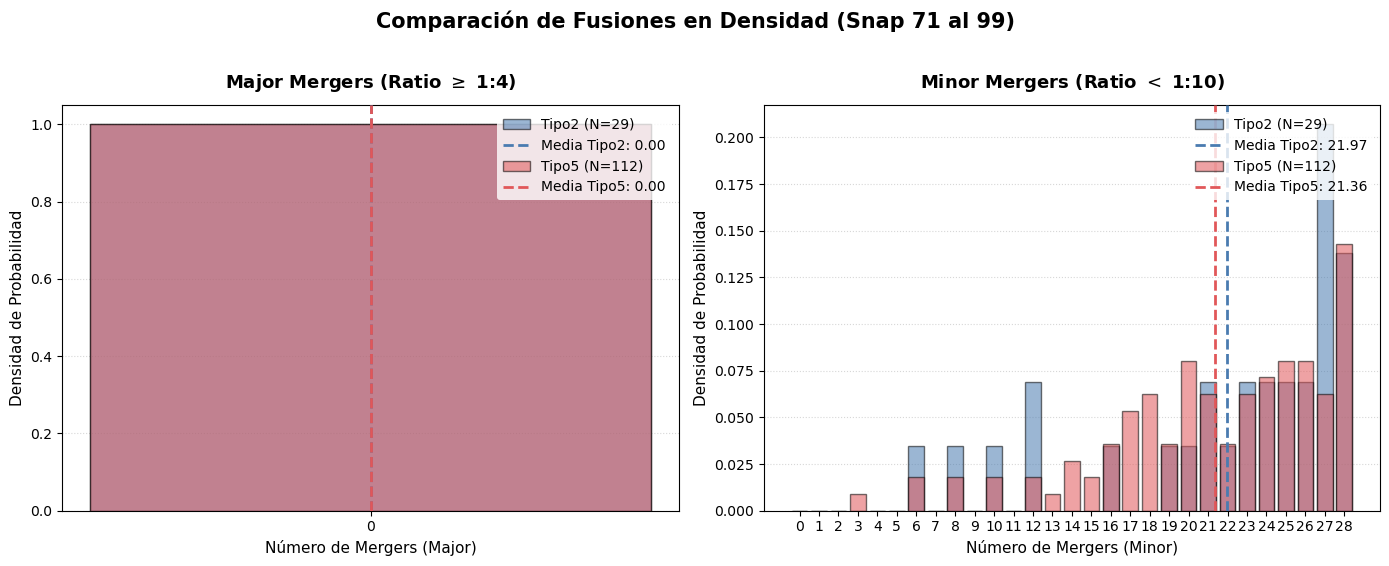

In [5]:
# ==========================================
# 4. GENERACIÓN DE HISTOGRAMAS SUPERPUESTOS (DENSIDAD)
# ==========================================
# Definimos los tipos que queremos comparar específicamente
tipos_a_graficar = ['Tipo2', 'Tipo5']  # Asegúrate de que coincidan exactamente con las etiquetas de tu archivo

# Creamos una figura con 2 subplots (uno para Major y otro para Minor)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Paleta de colores para la comparación
colores_tipos = {
    'Tipo2': '#4A7BB0',  # Azul moderno
    'Tipo5': '#E15759'   # Rojo/Coral
}

tipos_mergers = ['major', 'minor']
titulos = [
    r'Major Mergers (Ratio $\geq$ 1:4)', 
    r'Minor Mergers (Ratio $<$ 1:10)'
]

for idx, tipo_m in enumerate(tipos_mergers):
    ax = axes[idx]
    
    # 1. Encontrar el máximo global de mergers para este tipo entre las clases seleccionadas
    todos_los_datos = []
    for t in tipos_a_graficar:
        if t in conteos_mergers:
            todos_los_datos.extend(conteos_mergers[t][tipo_m])
            
    max_mergers = max(todos_los_datos) if len(todos_los_datos) > 0 else 3
    bins = np.arange(0, max_mergers + 2) - 0.5
    
    # 2. Graficar cada tipo de galaxia superpuesto
    for tipo_galaxia in tipos_a_graficar:
        if tipo_galaxia not in conteos_mergers:
            print(f"⚠️ El tipo {tipo_galaxia} no se encontró en los datos cargados.")
            continue
            
        datos = conteos_mergers[tipo_galaxia][tipo_m]
        n_galaxias = len(datos)
        
        if n_galaxias == 0:
            continue
            
        # Al usar density=True, el área total del histograma será igual a 1
        ax.hist(datos, bins=bins, rwidth=0.8, color=colores_tipos[tipo_galaxia], 
                edgecolor='black', alpha=0.55, density=True, label=f'{tipo_galaxia} (N={n_galaxias})',
                zorder=3)
        
        # Calcular y dibujar la línea de la media para cada tipo
        media = np.mean(datos)
        ax.axvline(media, color=colores_tipos[tipo_galaxia], linestyle='--', linewidth=2,
                   label=f'Media {tipo_galaxia}: {media:.2f}', zorder=4)

    # Estética del subplot
    ax.set_title(titulos[idx], fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel(f"Número de Mergers ({tipo_m.capitalize()})", fontsize=11)
    ax.set_ylabel("Densidad de Probabilidad", fontsize=11)
    
    ax.set_xticks(range(0, max_mergers + 1))
    ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
    ax.legend(frameon=True, loc='upper right', facecolor='white', edgecolor='none', fontsize=10)

# Título principal de la figura
plt.suptitle(f"Comparación de Fusiones en Densidad (Snap {snap_limite} al {snapshot_presente})", 
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()